# Pneumonia Detection Using Chest X-ray Images

This notebook implements an end-to-end binary image classification pipeline for **NORMAL vs PNEUMONIA** using the provided Chest X-ray dataset.

Outputs are saved in the `result/` folder:
- Trained model (`pneumonia_mobilenetv2.keras`)
- Training curves (`training_curves.png`)
- Confusion matrix (`confusion_matrix.png`)
- Metrics and report (`metrics.json`, `classification_report.csv`)

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / 'Dataset' / 'chest_xray'
RESULT_DIR = ROOT / 'result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 6
VAL_SPLIT = 0.15

print('TensorFlow:', tf.__version__)
print('Data dir exists:', DATA_DIR.exists())
print('Result dir:', RESULT_DIR.resolve())

TensorFlow: 2.17.1
Data dir exists: True
Result dir: C:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result


,split,class,count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,val,NORMAL,8
3,val,PNEUMONIA,8
4,test,NORMAL,234
5,test,PNEUMONIA,390


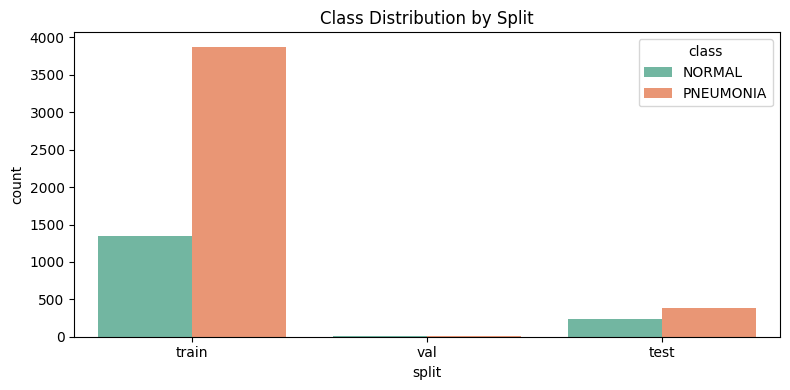

Saved: c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result\class_distribution.png


In [2]:
# Dataset inventory
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']
rows = []

for split in splits:
    for cls in classes:
        p = DATA_DIR / split / cls
        count = len([x for x in p.glob('*') if x.suffix.lower() in {'.jpg', '.jpeg', '.png'}]) if p.exists() else 0
        rows.append({'split': split, 'class': cls, 'count': count})

dist_df = pd.DataFrame(rows)
display(dist_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dist_df, x='split', y='count', hue='class', palette='Set2')
plt.title('Class Distribution by Split')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'class_distribution.png', dpi=180)
plt.show()

print('Saved:', RESULT_DIR / 'class_distribution.png')

In [3]:
# Data generators with preprocessing + augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.densenet.preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    validation_split=VAL_SPLIT,
)

eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.densenet.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED,
    subset='training',
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    subset='validation',
)

test_gen = eval_datagen.flow_from_directory(
    DATA_DIR / 'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

class_names = {v: k for k, v in train_gen.class_indices.items()}
print('Class indices:', train_gen.class_indices)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes,
)
class_weight = {int(i): float(w) for i, w in enumerate(weights)}
print('Class weights:', class_weight)
print('Train samples:', train_gen.samples)
print('Validation samples:', val_gen.samples)
print('Test samples:', test_gen.samples)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.944736842105263, 1: 0.6730418943533698}
Train samples: 4434
Validation samples: 782
Test samples: 624


In [4]:
# Model: DenseNet121 transfer learning
base_model = tf.keras.applications.DenseNet121(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ],
)

checkpoint_path = RESULT_DIR / 'best_pneumonia_densenet121.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

# Fine-tuning stage
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ],
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

# Ensure best checkpoint is loaded for evaluation
model = tf.keras.models.load_model(checkpoint_path)
print('Loaded best checkpoint:', checkpoint_path)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6709 - auc: 0.6840 - loss: 0.6574 - precision: 0.8545 - recall: 0.6873
Epoch 1: val_accuracy improved from None to 0.86957, saving model to c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result\best_pneumonia_densenet121.keras

Epoch 1: finished saving model to c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result\best_pneumonia_densenet121.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.7558 - auc: 0.8411 - loss: 0.4967 - precision: 0.9054 - recall: 0.7495 - val_accuracy: 0.8696 - val_auc: 0.9615 - val_loss: 0.3089 - val_precision: 0.9858 - val_recall: 0.8365 - learning_rate: 0.0010
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8678 - auc: 0.9467 - loss: 0.3014 - precision: 0.9589 - recall: 0.8597
Epoch 2: val_accuracy improved from 0.86957 to 0.87340, saving model to c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result\best_pneumonia_dense

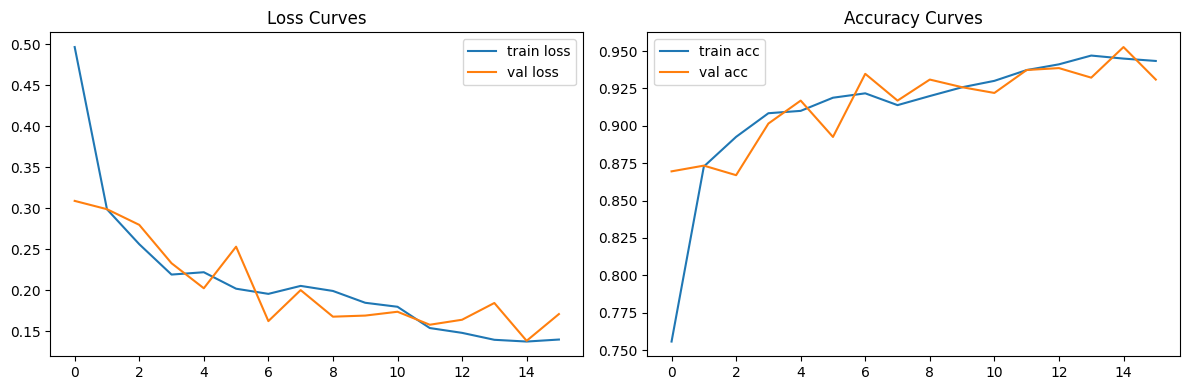

Saved model to: c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result\pneumonia_densenet121.keras


In [7]:
# Merge histories and save learning curves
hist = {}
for k in history.history.keys():
    hist[k] = history.history[k] + history_ft.history.get(k, [])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['loss'], label='train loss')
axes[0].plot(hist['val_loss'], label='val loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(hist['accuracy'], label='train acc')
axes[1].plot(hist['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULT_DIR / 'training_curves.png', dpi=180)
plt.show()

model_path = RESULT_DIR / 'pneumonia_densenet121.keras'
model.save(model_path)
print('Saved model to:', model_path)

20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
{'accuracy': 0.9134615384615384, 'precision': 0.917910447761194, 'recall': 0.9461538461538461, 'f1_score': 0.9318181818181818, 'roc_auc': 0.9668529476221783}


,precision,recall,f1-score,support
NORMAL,0.905405,0.858974,0.881579,234.000000
PNEUMONIA,0.917910,0.946154,0.931818,390.000000
accuracy,0.913462,0.913462,0.913462,0.913462
macro avg,0.911658,0.902564,0.906699,624.000000
weighted avg,0.913221,0.913462,0.912978,624.000000


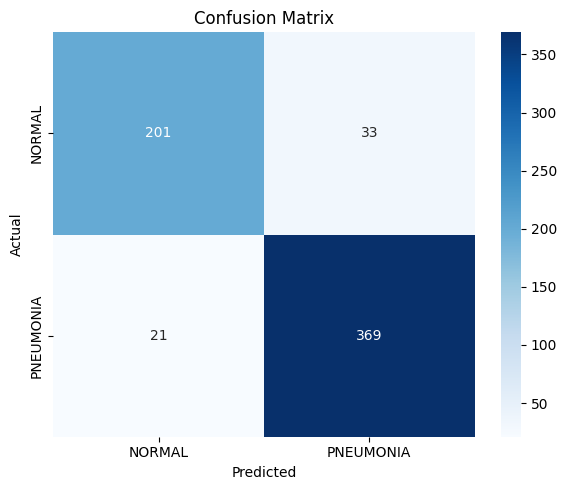

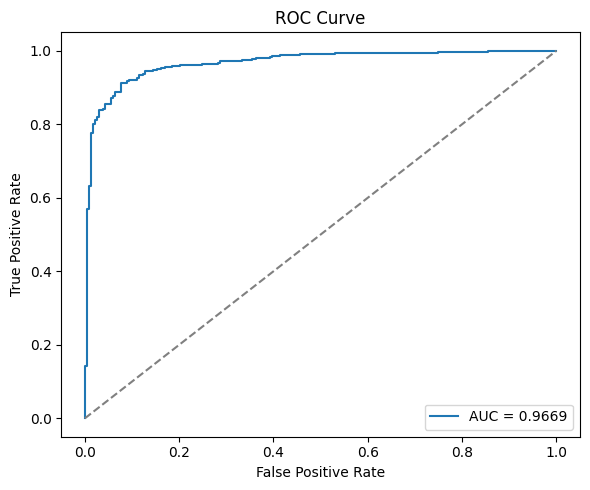

Saved results in: C:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\result


In [9]:
# Test evaluation and metrics export
test_gen.reset()
y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob)

metrics = {
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'roc_auc': float(auc),
}

print(metrics)

with open(RESULT_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

report = classification_report(
    y_true,
    y_pred,
    target_names=[class_names[0], class_names[1]],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(RESULT_DIR / 'classification_report.csv', index=True)
display(report_df)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[0], class_names[1]],
            yticklabels=[class_names[0], class_names[1]])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'roc_curve.png', dpi=180)
plt.show()

print('Saved results in:', RESULT_DIR.resolve())

Test accuracy: 0.9135
Test image: c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\Dataset\chest_xray\test\NORMAL\NORMAL2-IM-0146-0001.jpeg
True label: NORMAL
Predicted label: NORMAL
Confidence: 79.07%


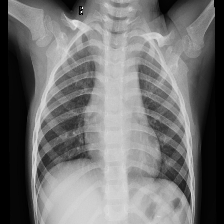

In [2]:
# Predict one test image and report the result
from pathlib import Path
import json
import random

import numpy as np
import tensorflow as tf
from IPython.display import display

WORKSPACE_DIR = Path(r'c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med')
DATASET_DIR = WORKSPACE_DIR / 'Dataset' / 'chest_xray' / 'test'
RESULT_DIR = WORKSPACE_DIR / 'result'
MODEL_PATH = RESULT_DIR / 'best_pneumonia_densenet121.keras'
METRICS_PATH = RESULT_DIR / 'metrics.json'
IMG_SIZE = (224, 224)
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Load the trained model and the saved evaluation metrics.
model = tf.keras.models.load_model(MODEL_PATH)
with open(METRICS_PATH, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

test_accuracy = metrics.get('accuracy', None)

# Pick one image from the test set. Prefer a reproducible random selection.
image_files = sorted(list((DATASET_DIR / 'NORMAL').glob('*')) + list((DATASET_DIR / 'PNEUMONIA').glob('*')))
if not image_files:
    raise FileNotFoundError(f'No test images found under {DATASET_DIR}')

random.seed(42)
image_path = random.choice(image_files)
true_label = image_path.parent.name

# Prepare the image exactly like the DenseNet pipeline expects.
image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
image_array = tf.keras.utils.img_to_array(image)
image_array = tf.keras.applications.densenet.preprocess_input(image_array)
image_batch = np.expand_dims(image_array, axis=0)

# Run inference.
probability = float(model.predict(image_batch, verbose=0).ravel()[0])
predicted_label = CLASS_NAMES[1] if probability >= 0.5 else CLASS_NAMES[0]
confidence = probability if predicted_label == CLASS_NAMES[1] else 1.0 - probability

print(f'Test accuracy: {test_accuracy:.4f}' if test_accuracy is not None else 'Test accuracy: unavailable')
print(f'Test image: {image_path}')
print(f'True label: {true_label}')
print(f'Predicted label: {predicted_label}')
print(f'Confidence: {confidence * 100:.2f}%')

display(image)


Test accuracy: 0.9135
Selected image: C:\Users\Banoth Arun\OneDrive\Desktop\Bio_med\Random_images\What-Can-X-Rays-Detect-18.jpg
Predicted label: PNEUMONIA
Confidence: 99.23%


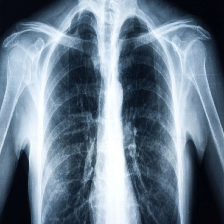

In [7]:
# Choose an image from the workspace and run prediction
from pathlib import Path
import json

import numpy as np
import tensorflow as tf
from IPython.display import display
from tkinter import Tk, filedialog

WORKSPACE_DIR = Path(r'c:\Users\Banoth Arun\OneDrive\Desktop\Bio_med')
RESULT_DIR = WORKSPACE_DIR / 'result'
MODEL_PATH = RESULT_DIR / 'best_pneumonia_densenet121.keras'
METRICS_PATH = RESULT_DIR / 'metrics.json'
IMG_SIZE = (224, 224)
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Reuse loaded objects when available; otherwise load them here.
if 'model' not in globals():
    model = tf.keras.models.load_model(MODEL_PATH)

if 'test_accuracy' not in globals():
    with open(METRICS_PATH, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    test_accuracy = metrics.get('accuracy', None)

# Open a file picker rooted at the workspace so you can select any image directly.
root = Tk()
root.withdraw()
root.attributes('-topmost', True)
image_path_str = filedialog.askopenfilename(
    title='Choose an image to classify',
    initialdir=str(WORKSPACE_DIR),
    filetypes=[
        ('Image files', '*.jpg *.jpeg *.png *.bmp *.webp'),
        ('All files', '*.*'),
    ],
)
root.destroy()

if not image_path_str:
    raise ValueError('No image selected.')

image_path = Path(image_path_str)
if not image_path.exists():
    raise FileNotFoundError(f'Image not found: {image_path}')

# Preprocess the selected image using the same DenseNet pipeline as training.
image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
image_array = tf.keras.utils.img_to_array(image)
image_array = tf.keras.applications.densenet.preprocess_input(image_array)
image_batch = np.expand_dims(image_array, axis=0)

# Predict and report confidence.
probability = float(model.predict(image_batch, verbose=0).ravel()[0])
predicted_label = CLASS_NAMES[1] if probability >= 0.5 else CLASS_NAMES[0]
confidence = probability if predicted_label == CLASS_NAMES[1] else 1.0 - probability

print(f'Test accuracy: {test_accuracy:.4f}' if test_accuracy is not None else 'Test accuracy: unavailable')
print(f'Selected image: {image_path}')
print(f'Predicted label: {predicted_label}')
print(f'Confidence: {confidence * 100:.2f}%')

display(image)
